# LangGraph Getting Started: Simple Graph Tutorial

## Overview
This notebook demonstrates the fundamental concepts of LangGraph by creating a simple sequential graph with three nodes.

**What you'll learn:**
- How to define a state using `TypedDict`
- How to create nodes that process state
- How to build a graph using `StateGraph`
- How to connect edges and execute the graph

In [ ]:
# Import Required Libraries for LangGraph
from typing_extensions import TypedDict  # For type-safe state definition
from langgraph.graph import StateGraph, START, END  # Core LangGraph components

## State Definition: TypedDict vs BaseModel

### TypedDict
- **Type checking**: Checked by type checker at compile time
- **Runtime enforcement**: Not enforced by Python runtime
- **Use case**: Lightweight type hints for dictionaries

### BaseModel (Pydantic)
- **Runtime validation**: Enforced when your code runs at runtime
- **Data validation**: Validates data structure and types
- **Use case**: When you need strict runtime validation

For LangGraph state, we use `TypedDict` for type safety without runtime overhead.

In [ ]:
# Define the State Schema
# This defines the structure of data that flows through our graph
class SimpleState(TypedDict):
    input_text: str      # Input text to be processed
    output_text: str     # Output text after processing by nodes

In [ ]:
# Create an example state instance
example_state = SimpleState(input_text="hello", output_text="HELLO")
print("Example State:", example_state)

{'input_text': 'hello', 'output_text': 'HELLO'}

## Define Graph Nodes

Each node is a function that:
1. Takes the current state as input
2. Processes the state
3. Returns an updated state

In this example, each node appends a message to `output_text` to show processing order.

In [ ]:
# Node 1: First processing step
# Receives state and appends a completion message
def node1(state: SimpleState) -> SimpleState:
    # Append node1 completion message to output_text
    return SimpleState(
        input_text="hello", 
        output_text=state["input_text"] + " node1 is done "
    )

In [ ]:
# Node 2: Second processing step
# Receives output from node1 and appends its completion message
def node2(state: SimpleState) -> SimpleState:
    # Append node2 completion message to existing output
    return SimpleState(
        input_text="hello", 
        output_text=state["output_text"] + " node2 is done "
    )

In [ ]:
# Node 3: Third processing step
# Receives output from node2 and appends its completion message
def node3(state: SimpleState) -> SimpleState:
    # Append node3 completion message to existing output
    return SimpleState(
        input_text="hello", 
        output_text=state["output_text"] + "node3 is done "
    )

In [ ]:
# Build the Graph
# This function creates a sequential graph: START -> node1 -> node2 -> node3 -> END
def create_simple_graph():
    # Initialize the state graph with SimpleState schema
    builder = StateGraph(SimpleState)

    # Add nodes to the graph
    builder.add_node("node1", node1)
    builder.add_node("node2", node2)
    builder.add_node("node3", node3)

    # Connect edges to define execution flow
    builder.add_edge(START, "node1")      # Start -> node1
    builder.add_edge("node1", "node2")    # node1 -> node2
    builder.add_edge("node2", "node3")    # node2 -> node3
    builder.add_edge("node3", END)        # node3 -> End

    # Compile the graph into a LangChain runnable
    graph = builder.compile()

    return graph

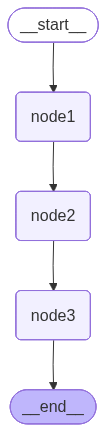

In [ ]:
# Create and Visualize the Graph
graph = create_simple_graph()

# Display the graph structure (visual representation)
graph

In [ ]:
# Execute the Graph
# Create initial state with input text
initial_state = {'input_text': "hello"}

# Invoke the graph and get the final result
result = graph.invoke(initial_state)

print("Final Result:")
print(result)

{'input_text': 'hello',
 'output_text': 'hello node1 is done  node2 is done node3 is done '}

## Advanced Features: Error Handling and Graph Analysis

In this section, we'll explore:
1. **Error Handling**: Gracefully handling exceptions during graph execution
2. **State Inspection**: Analyzing the state at each step
3. **Graph Introspection**: Understanding graph structure and node properties

In [ ]:
# Error Handling: Execute graph with try-except block
# This demonstrates robust error handling in graph execution

try:
    # Create the graph for execution
    graph = create_simple_graph()
    
    # Test with multiple inputs to verify consistency
    test_inputs = [
        {'input_text': "hello"},
        {'input_text': "langgraph"},
        {'input_text': "python"}
    ]
    
    print("=" * 60)
    print("GRAPH EXECUTION WITH ERROR HANDLING")
    print("=" * 60)
    
    # Execute graph for each test input
    for i, test_input in enumerate(test_inputs, 1):
        try:
            # Invoke the graph with the test input
            result = graph.invoke(test_input)
            
            print(f"\nTest Case {i}:")
            print(f"  Input:  {test_input['input_text']}")
            print(f"  Output: {result['output_text']}")
            print(f"  Status: ✓ Success")
            
        except Exception as node_error:
            # Handle errors at node level
            print(f"\nTest Case {i}:")
            print(f"  Input:  {test_input['input_text']}")
            print(f"  Error:  {str(node_error)}")
            print(f"  Status: ✗ Failed")
    
    print("\n" + "=" * 60)
    print("All test cases completed successfully!")
    print("=" * 60)
    
except Exception as graph_error:
    # Handle errors at graph level
    print(f"Graph Execution Error: {str(graph_error)}")

In [ ]:
# Graph Introspection: Analyze graph structure and properties
# This demonstrates advanced techniques for understanding graph composition

# Create a fresh graph instance for analysis
analysis_graph = create_simple_graph()

print("\n" + "=" * 60)
print("GRAPH STRUCTURE ANALYSIS")
print("=" * 60)

# Access graph metadata and configuration
print(f"\nGraph Type: {type(analysis_graph).__name__}")
print(f"Graph Module: {type(analysis_graph).__module__}")

# Analyze graph configuration
if hasattr(analysis_graph, 'get_config'):
    config = analysis_graph.get_config()
    print(f"\nGraph Configuration:")
    print(f"  - Config Keys: {list(config.keys()) if config else 'None'}")

# Display graph input/output schema
if hasattr(analysis_graph, 'input_schema'):
    print(f"\nGraph Input Schema:")
    print(f"  - Type: {analysis_graph.input_schema}")

if hasattr(analysis_graph, 'output_schema'):
    print(f"\nGraph Output Schema:")
    print(f"  - Type: {analysis_graph.output_schema}")

# Demonstrate StateGraph features
print(f"\nGraph Execution Method: invoke()")
print(f"Alternative Methods: batch(), stream()")

print("\n" + "=" * 60)
print("Graph analysis completed!")
print("=" * 60)